# importing pandas

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../data/raw/returning_customer.csv")

# **EDA activities - exploring and investigating data**

In [3]:
df.head()

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,ORD_000001-1,CUST_00001,29-05-2023,40,Male,Ankara,Books,29.18,1,0.00,29.18,Digital Wallet,Mobile,14,9,True,13,4
1,ORD_000001-2,CUST_00001,12-10-2023,40,Male,Ankara,Home & Garden,644.40,1,138.05,506.35,Credit Card,Desktop,14,8,True,6,2
2,ORD_000001-3,CUST_00001,05-12-2023,40,Male,Ankara,Sports,332.82,5,0.00,1664.10,Credit Card,Mobile,15,10,True,9,4
3,ORD_000002-1,CUST_00002,11-05-2023,33,Male,Istanbul,Food,69.30,5,71.05,275.45,Digital Wallet,Desktop,16,13,True,4,4
4,ORD_000002-2,CUST_00002,16-06-2023,33,Male,Istanbul,Beauty,178.15,3,0.00,534.45,Credit Card,Mobile,14,7,True,6,4


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22049 entries, 0 to 22048
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order_ID                  22049 non-null  object 
 1   Customer_ID               22049 non-null  object 
 2   Date                      22049 non-null  object 
 3   Age                       22049 non-null  int64  
 4   Gender                    22049 non-null  object 
 5   City                      22049 non-null  object 
 6   Product_Category          22049 non-null  object 
 7   Unit_Price                22049 non-null  float64
 8   Quantity                  22049 non-null  int64  
 9   Discount_Amount           22049 non-null  float64
 10  Total_Amount              22049 non-null  float64
 11  Payment_Method            22049 non-null  object 
 12  Device_Type               22049 non-null  object 
 13  Session_Duration_Minutes  22049 non-null  int64  
 14  Pages_

In [5]:
df.isnull().sum()

Order_ID                    0
Customer_ID                 0
Date                        0
Age                         0
Gender                      0
City                        0
Product_Category            0
Unit_Price                  0
Quantity                    0
Discount_Amount             0
Total_Amount                0
Payment_Method              0
Device_Type                 0
Session_Duration_Minutes    0
Pages_Viewed                0
Is_Returning_Customer       0
Delivery_Time_Days          0
Customer_Rating             0
dtype: int64

In [6]:
df.describe()

,Age,Unit_Price,Quantity,Discount_Amount,Total_Amount,Session_Duration_Minutes,Pages_Viewed,Delivery_Time_Days,Customer_Rating
count,22049.000000,22049.000000,22049.000000,22049.000000,22049.000000,22049.000000,22049.000000,22049.000000,22049.000000
mean,34.965441,449.700508,2.831920,59.598256,1210.694234,14.544197,8.998821,6.502109,3.900177
std,11.054313,720.091114,1.451207,216.621317,2265.755590,4.862567,2.394224,3.483322,1.128719
min,18.000000,5.050000,1.000000,0.000000,6.210000,1.000000,1.000000,1.000000,1.000000
25%,27.000000,74.050000,1.000000,0.000000,159.800000,12.000000,7.000000,4.000000,3.000000
50%,35.000000,177.110000,3.000000,0.000000,429.920000,14.000000,9.000000,6.000000,4.000000
75%,42.000000,499.360000,4.000000,25.080000,1199.060000,17.000000,11.000000,8.000000,5.000000
max,75.000000,7900.010000,5.000000,6538.290000,37852.050000,73.000000,24.000000,25.000000,5.000000


In [7]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
22044    False
22045    False
22046    False
22047    False
22048    False
Length: 22049, dtype: bool

# Outliers identifying

In [8]:
corr_mat = df.corr(numeric_only = True)
corr_mat

,Age,Unit_Price,Quantity,Discount_Amount,Total_Amount,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
Age,1.000000,-0.002771,0.000469,0.004638,-0.003931,0.007649,-0.006757,0.004177,-0.002798,-0.004795
Unit_Price,-0.002771,1.000000,-0.003085,0.452236,0.847827,-0.008160,0.012384,0.006701,-0.015806,-0.000933
Quantity,0.000469,-0.003085,1.000000,0.128931,0.274324,-0.006377,-0.002015,0.068747,-0.000459,-0.006229
Discount_Amount,0.004638,0.452236,0.128931,1.000000,0.439709,-0.003228,-0.002262,0.027210,-0.010054,0.002864
Total_Amount,-0.003931,0.847827,0.274324,0.439709,1.000000,-0.005793,0.004270,0.016130,-0.013794,0.001730
Session_Duration_Minutes,0.007649,-0.008160,-0.006377,-0.003228,-0.005793,1.000000,0.014766,-0.006893,0.006181,0.009394
Pages_Viewed,-0.006757,0.012384,-0.002015,-0.002262,0.004270,0.014766,1.000000,0.009138,0.009605,-0.007244
Is_Returning_Customer,0.004177,0.006701,0.068747,0.027210,0.016130,-0.006893,0.009138,1.000000,0.002410,0.002468
Delivery_Time_Days,-0.002798,-0.015806,-0.000459,-0.010054,-0.013794,0.006181,0.009605,0.002410,1.000000,-0.008812
Customer_Rating,-0.004795,-0.000933,-0.006229,0.002864,0.001730,0.009394,-0.007244,0.002468,-0.008812,1.000000


In [19]:
def z_score(col):
    z= ((df[col]-df[col].mean())/df[col].std()).abs()
    outlier = (z>3).sum()
    return outlier

def IQR_method(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier = ((df[col]<lower) | (df[col]>upper)).sum()
    return outlier

num_cols = [x for x in df.columns if df[x].dtype in ["int64", "float64"]]
df= df.drop(columns=["Order_ID", "Customer_ID"])
cat_cols = [x for x in df.columns if df[x].dtype == "object"]

for col in num_cols:
    z = z_score(col)
    IQR = IQR_method(col)
    print(f"Column name: {col} - Z score: {z}, IQR: {IQR}")

Column name: Age - Z score: 49, IQR: 128
Column name: Unit_Price - Z score: 570, IQR: 2269
Column name: Quantity - Z score: 0, IQR: 0
Column name: Discount_Amount - Z score: 409, IQR: 3686
Column name: Total_Amount - Z score: 502, IQR: 2501
Column name: Session_Duration_Minutes - Z score: 318, IQR: 1024
Column name: Pages_Viewed - Z score: 54, IQR: 15
Column name: Delivery_Time_Days - Z score: 316, IQR: 616
Column name: Customer_Rating - Z score: 0, IQR: 0


In [20]:
for x in cat_cols:
    print(len(df[x]))

22049
22049
22049
22049
22049
22049


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

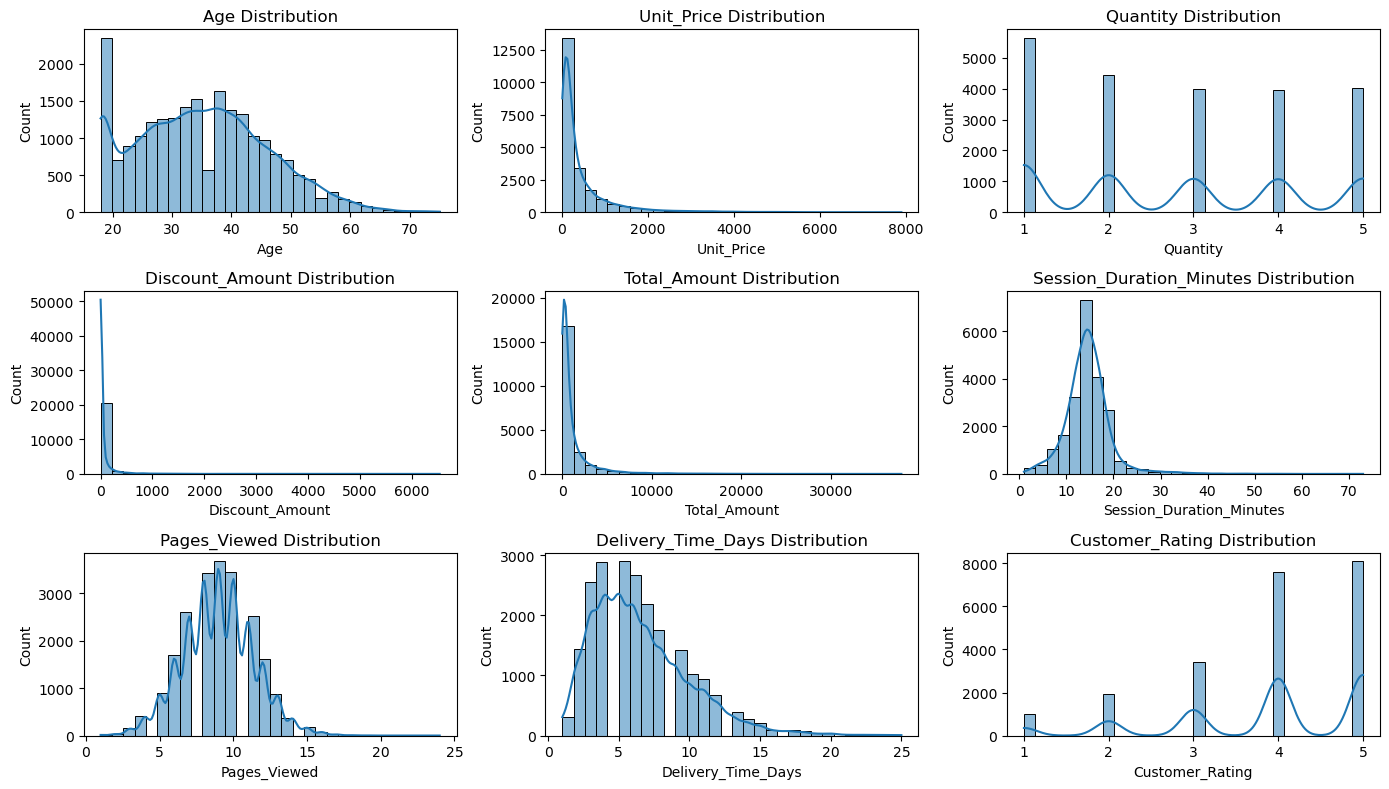

In [13]:
plt.figure(figsize=(14, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True,bins=30)
    plt.title(f"{col} Distribution")
plt.tight_layout()
plt.show()

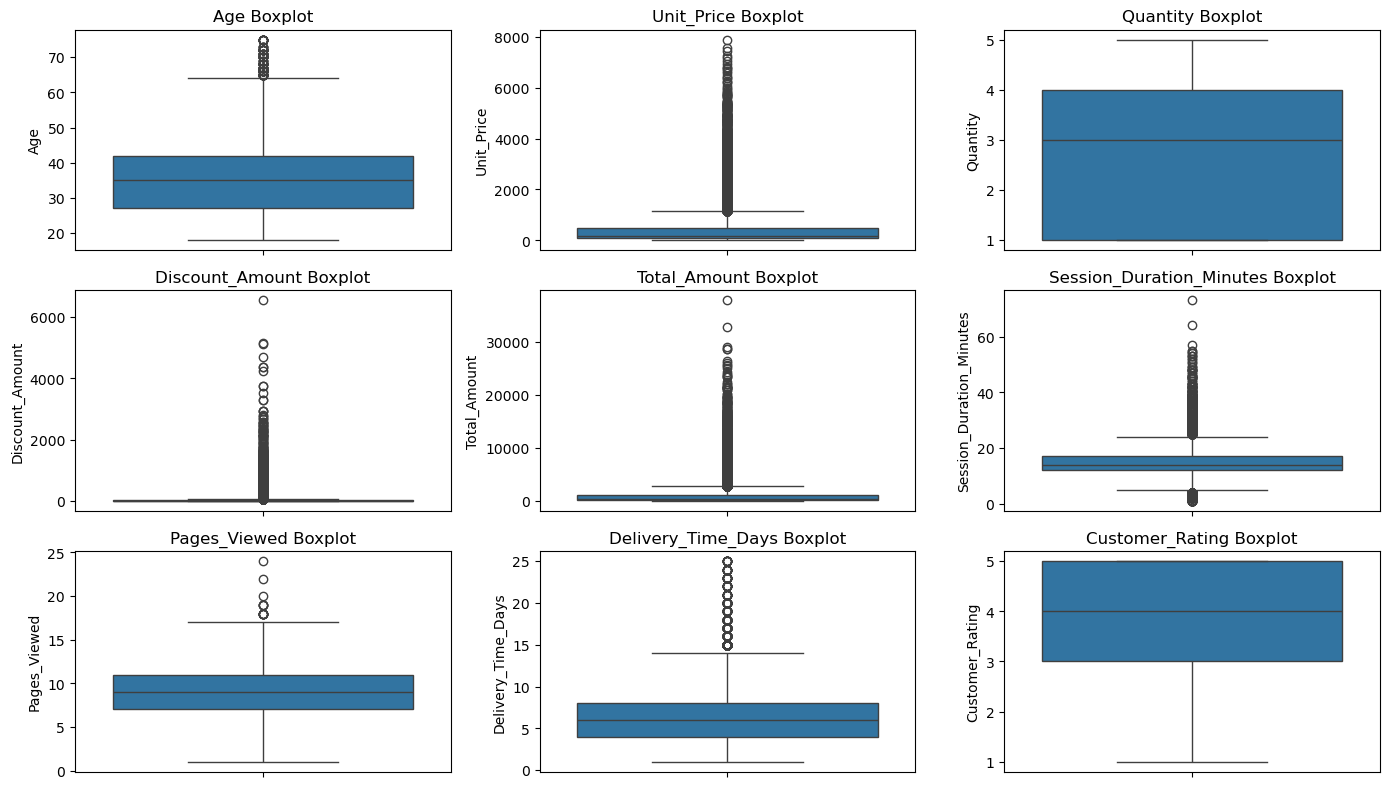

In [14]:
plt.figure(figsize=(14, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(df[col])
    plt.title(f"{col} Boxplot")
plt.tight_layout()
plt.show()

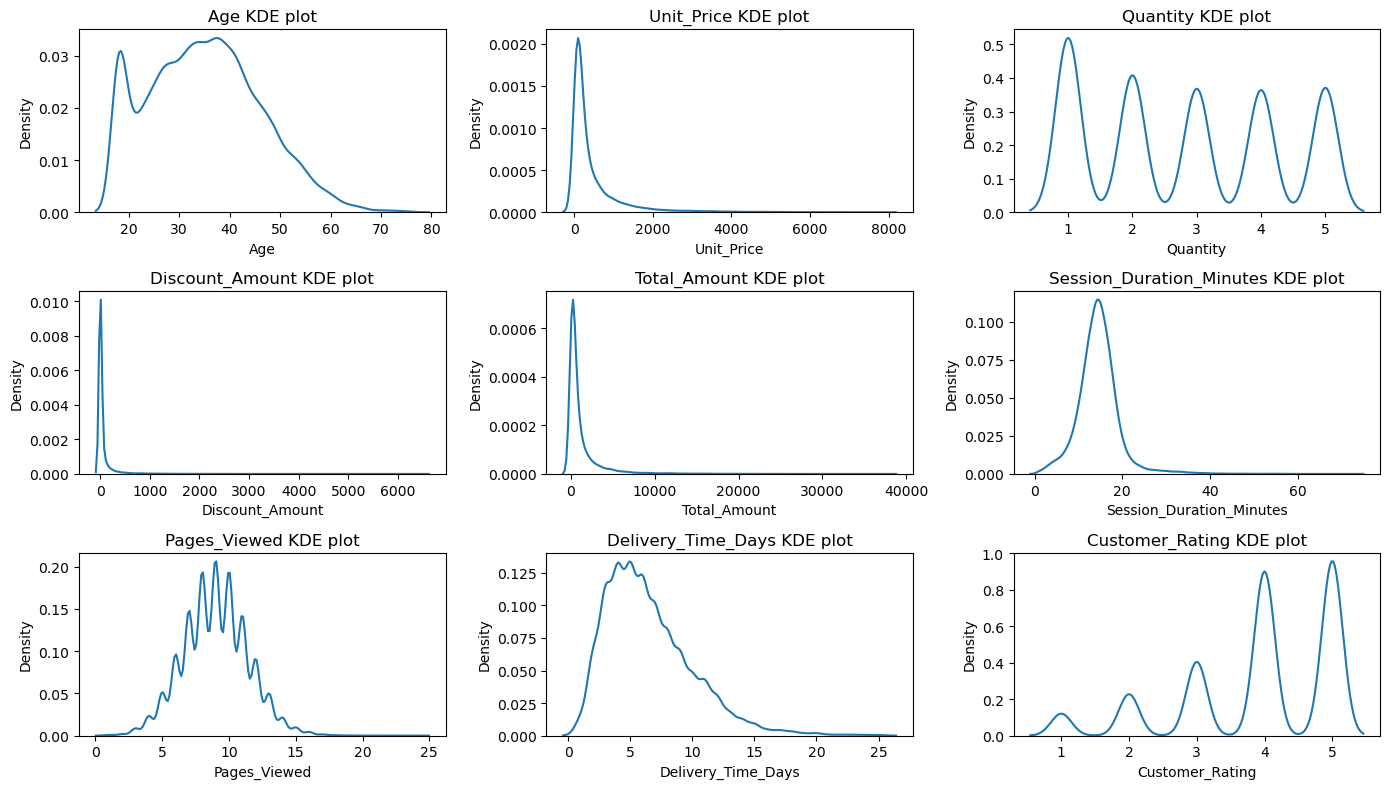

In [15]:
plt.figure(figsize=(14, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.kdeplot(df[col])
    plt.title(f"{col} KDE plot")
plt.tight_layout()
plt.show()

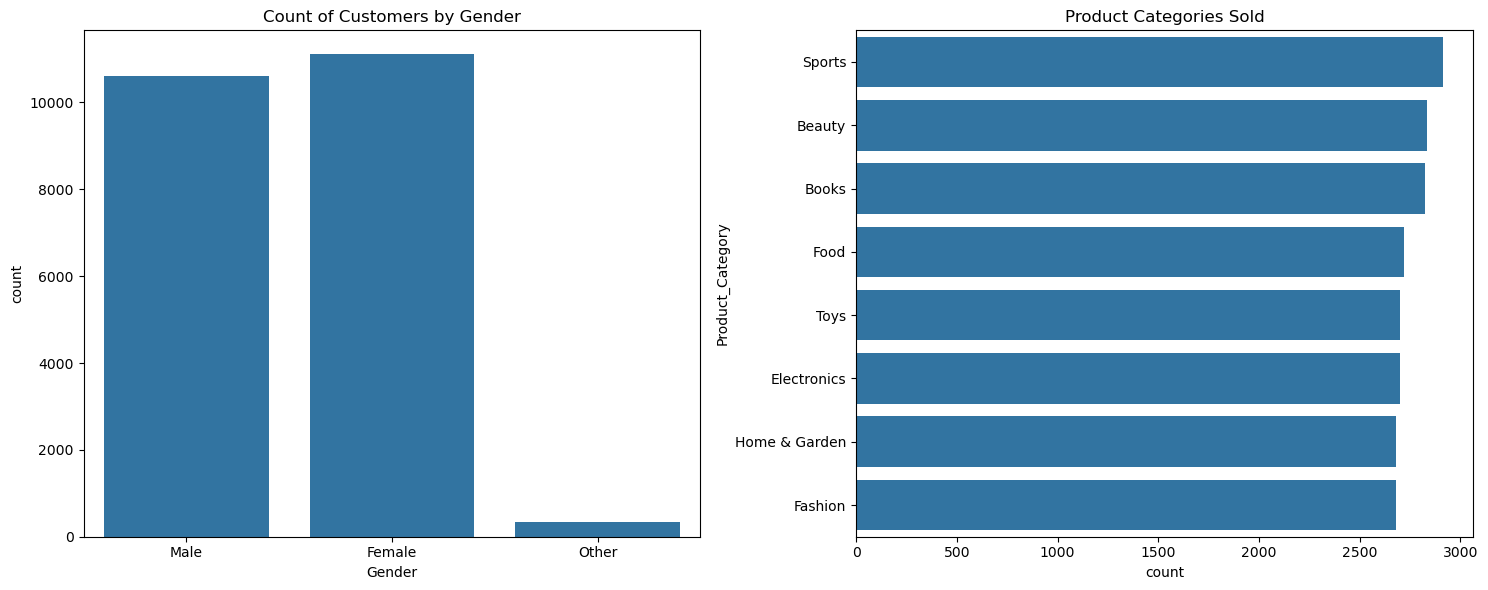

In [31]:
plt.figure(figsize=(15, 6))

plt.subplot(1,2,1)
sns.countplot(x="Gender", data=df)
plt.title("Count of Customers by Gender")

plt.subplot(1,2,2)
sns.countplot(y="Product_Category", data=df, order=df["Product_Category"].value_counts().index)
plt.title("Product Categories Sold") 

plt.tight_layout()
plt.show()

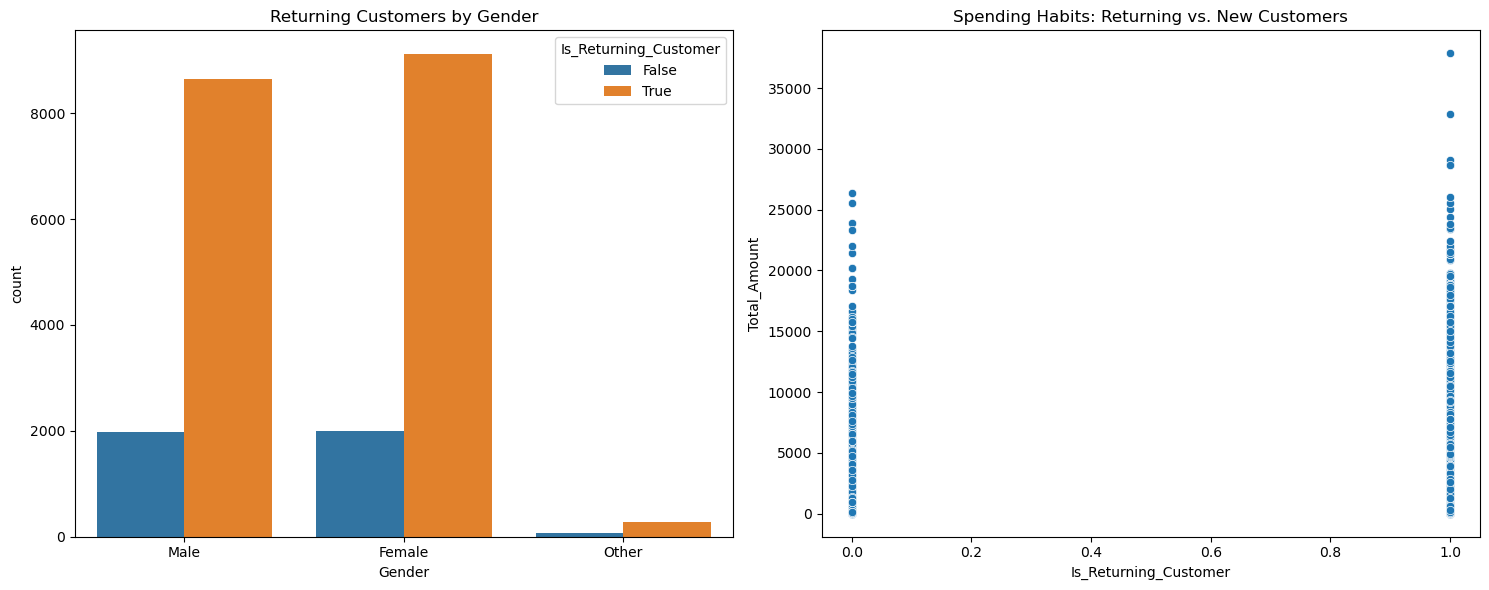

In [35]:
plt.figure(figsize=(15, 6))

plt.subplot(1,2,1)
sns.countplot(x="Gender", hue="Is_Returning_Customer", data=df)
plt.title("Returning Customers by Gender")

plt.subplot(1,2,2)
sns.scatterplot(x="Is_Returning_Customer", y="Total_Amount", data=df)
plt.title("Spending Habits: Returning vs. New Customers") 

plt.tight_layout()
plt.show()

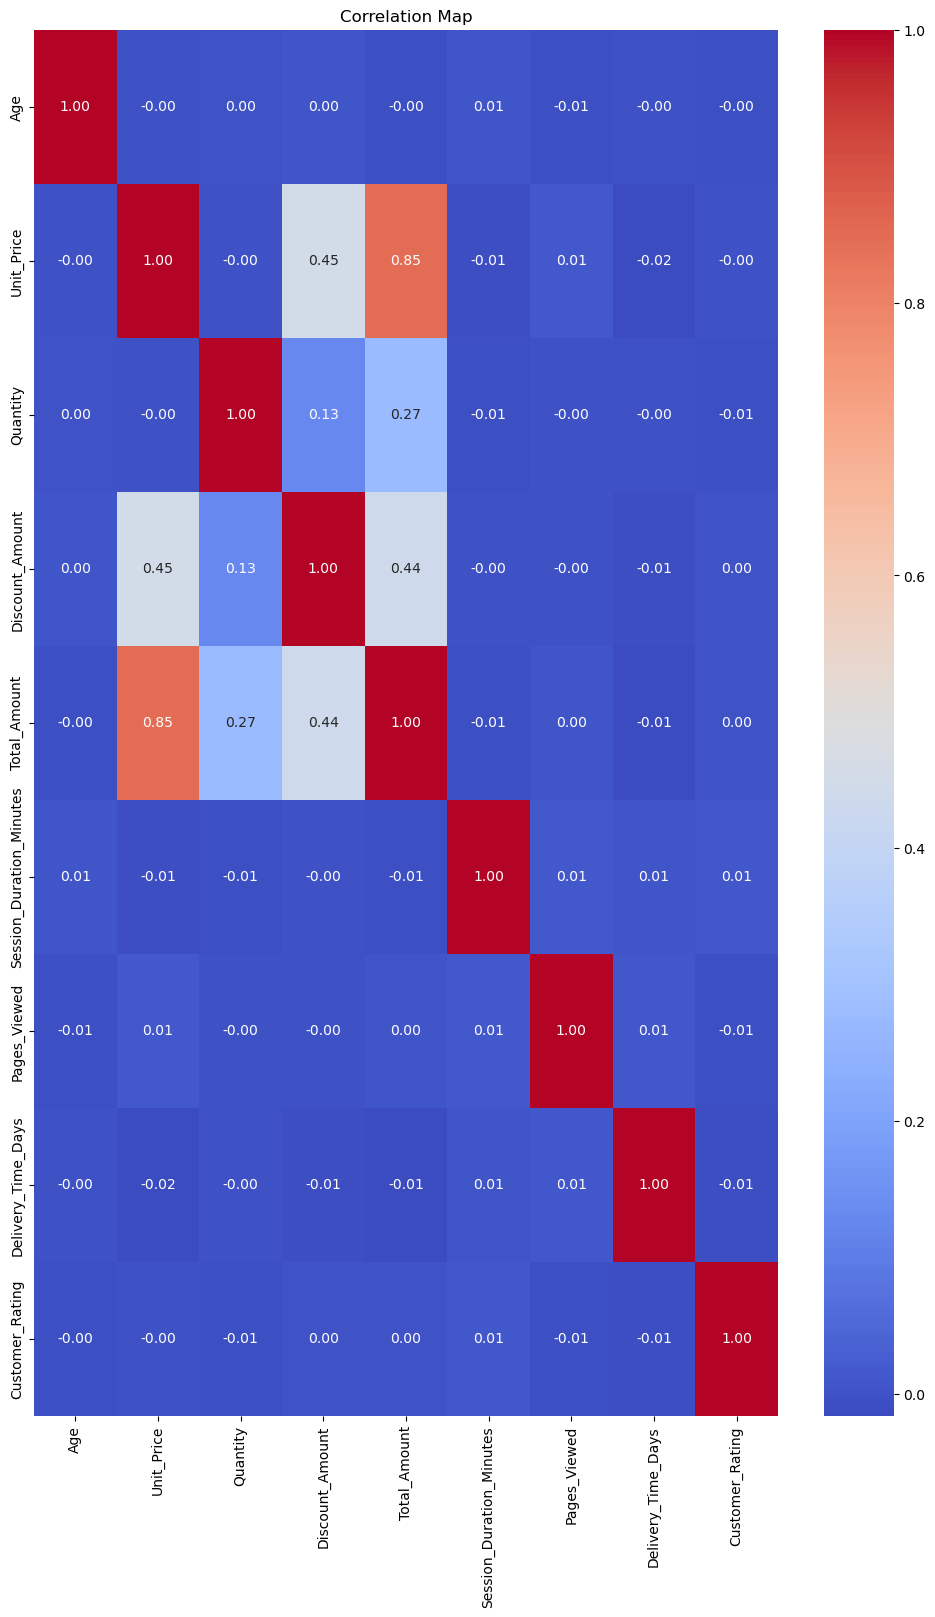

In [39]:
num_df = df.select_dtypes(include=["number"])
plt.figure(figsize=(12, 18))
sns.heatmap(num_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Map")
plt.show()